In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df_dc3 = pd.read_csv("../logs/latency_dc3.log")
df_dc3.head()

,str_len,alph,run,latency_ms
0,1000,4.0,0.0,1.303
1,1000,4.0,1.0,2.598
2,1000,4.0,2.0,2.172
3,1000,4.0,3.0,2.002
4,1000,4.0,4.0,1.402


In [3]:
def get_mode(x):
    return x.mode().iloc[0]  # pick the first mode if multiple

mode_df = (
    df_dc3.groupby(['str_len', 'alph'])['latency_ms']
      .apply(get_mode)
      .reset_index()
)

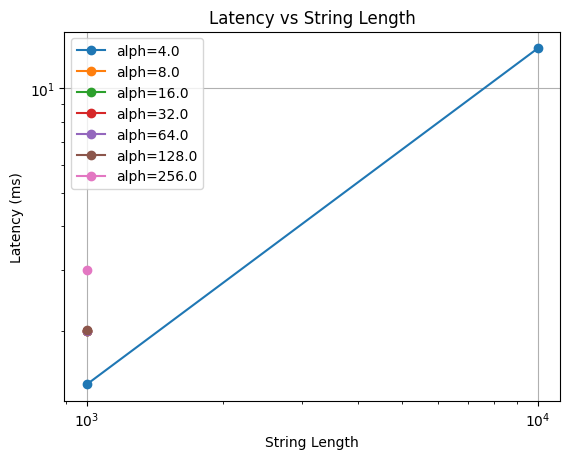

In [4]:
for alph_value in mode_df['alph'].unique():
    subset = mode_df[mode_df['alph'] == alph_value]
    
    plt.plot(subset['str_len'], subset['latency_ms'], marker='o', label=f'alph={alph_value}')

plt.xlabel('String Length')
plt.ylabel('Latency (ms)') # Mode
plt.title('Latency vs String Length') # Mode
plt.legend()
plt.grid()

plt.xscale("log")
plt.yscale("log")

plt.show()

In [5]:
# Group and compute median
median_df = (
    df_dc3.groupby(['str_len', 'alph'])['latency_ms']
      .median()
      .reset_index()
)

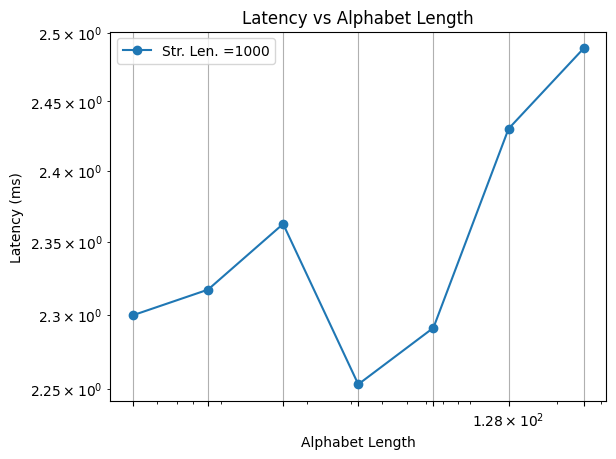

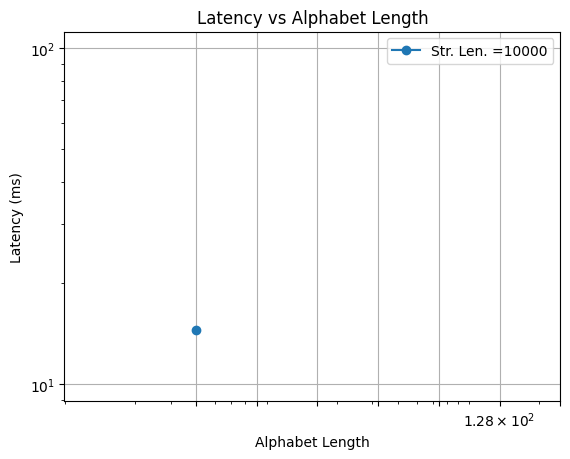

In [6]:
for str_value in median_df['str_len'].unique():
    subset = median_df[median_df['str_len'] == str_value]
    
    plt.plot(subset['alph'], subset['latency_ms'], marker='o', label=f'Str. Len. ={str_value}')

    plt.xlabel('Alphabet Length')
    plt.ylabel('Latency (ms)') # Mode
    plt.title('Latency vs Alphabet Length') # Mode
    plt.legend()
    plt.grid()

    plt.xscale("log")
    plt.yscale("log")

    plt.xticks([4,8,16,32,64,128,256])

    plt.show()

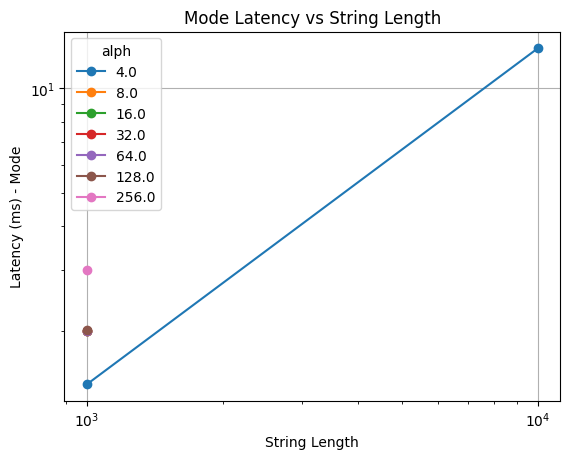

In [7]:
pivot_df = mode_df.pivot(index='str_len', columns='alph', values='latency_ms')

pivot_df.plot(marker='o')

plt.xlabel('String Length')
plt.ylabel('Latency (ms) - Mode')
plt.title('Mode Latency vs String Length')
plt.grid()
plt.xscale("log")
plt.yscale("log")

plt.show()

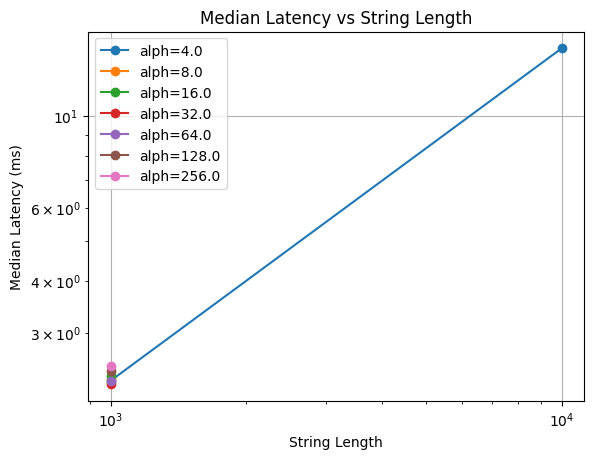

In [8]:
for alph_value in median_df['alph'].unique():
    subset = median_df[median_df['alph'] == alph_value]
    
    plt.plot(subset['str_len'], subset['latency_ms'], marker='o', label=f'alph={alph_value}')

plt.xlabel('String Length')
plt.ylabel('Median Latency (ms)')
plt.title('Median Latency vs String Length')
plt.legend()
plt.grid()

plt.xscale("log")
plt.yscale("log")

plt.show()

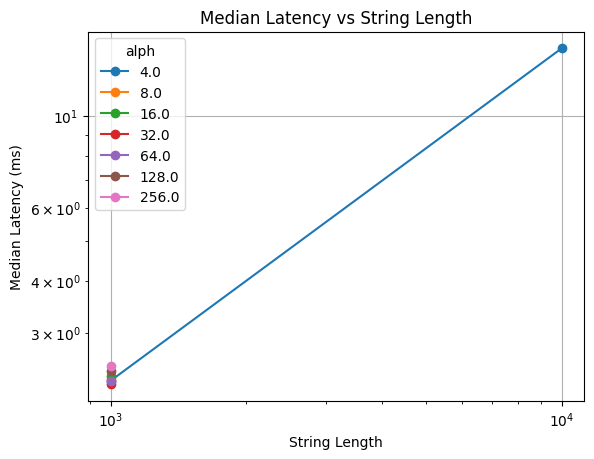

In [9]:
pivot_df = median_df.pivot(index='str_len', columns='alph', values='latency_ms')

pivot_df.plot(marker='o')

plt.xlabel('String Length')
plt.ylabel('Median Latency (ms)')
plt.title('Median Latency vs String Length')
plt.grid()

plt.xscale("log")
plt.yscale("log")

plt.show()


In [10]:
df_dc3_all = (
    mode_df.groupby(['str_len'])['latency_ms']
      .mean()
      .reset_index()
)

In [11]:
mode_df

,str_len,alph,latency_ms
0,1000,4.0,1.402
1,1000,8.0,2.002
2,1000,16.0,1.999
3,1000,32.0,2.000
4,1000,64.0,1.998
5,1000,128.0,2.005
6,1000,256.0,3.000
7,10000,4.0,13.009


In [12]:
df_dc3_all

,str_len,latency_ms
0,1000,2.058
1,10000,13.009


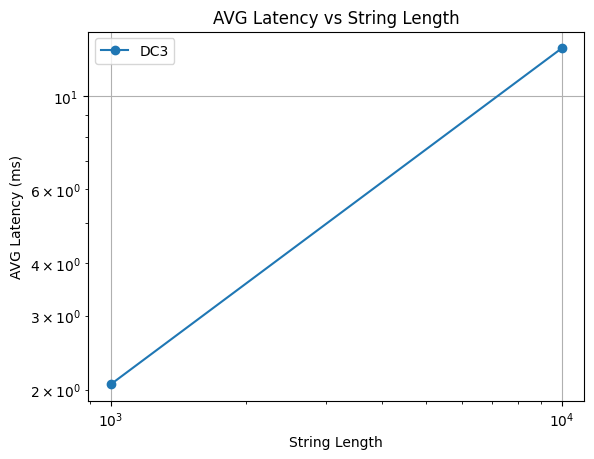

In [13]:
plt.plot(df_dc3_all['str_len'], df_dc3_all['latency_ms'], marker='o', label="DC3")

plt.xlabel('String Length')
plt.ylabel('AVG Latency (ms)')
plt.title('AVG Latency vs String Length')
plt.legend()
plt.grid()

plt.xscale("log")
plt.yscale("log")

plt.show()

# include doubling O(nlogn) Algorithm to compare

In [14]:
df_db = pd.read_csv("../logs/latency_doubling.log")
df_db.head()

,str_len,alph,run,latency_ms
0,1000,4,0,1.008
1,1000,4,1,1.000
2,1000,8,0,1.017
3,1000,8,1,1.000
4,1000,16,0,1.000


In [15]:
# Remove latency equal 0
df_db = df_db[df_db['latency_ms'] != 0]

In [16]:
mode_df_db = (
    df_db.groupby(['str_len', 'alph'])['latency_ms']
      .apply(get_mode)
      .reset_index()
)

In [17]:
df_db_all = (
    mode_df_db.groupby(['str_len'])['latency_ms']
      .mean()
      .reset_index()
)

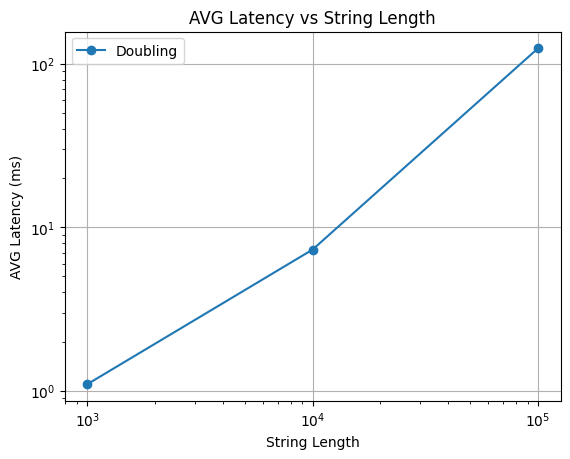

In [18]:
plt.plot(df_db_all['str_len'], df_db_all['latency_ms'], marker='o', label="Doubling")

plt.xlabel('String Length')
plt.ylabel('AVG Latency (ms)')
plt.title('AVG Latency vs String Length')
plt.legend()
plt.grid()

plt.xscale("log")
plt.yscale("log")

plt.show()

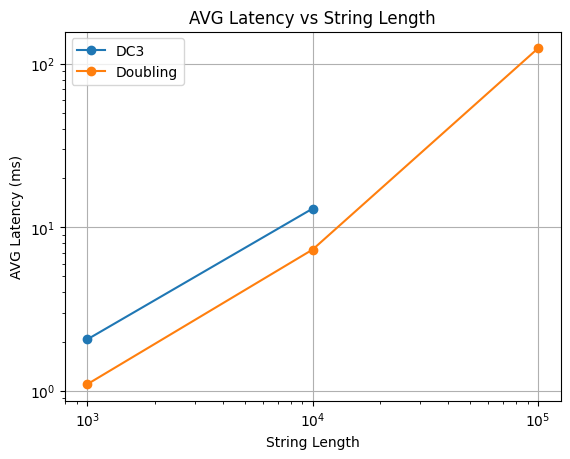

In [19]:
plt.plot(df_dc3_all['str_len'], df_dc3_all['latency_ms'], marker='o', label="DC3")
plt.plot(df_db_all['str_len'], df_db_all['latency_ms'], marker='o', label="Doubling")

plt.xlabel('String Length')
plt.ylabel('AVG Latency (ms)')
plt.title('AVG Latency vs String Length')
plt.legend()
plt.grid()

plt.xscale("log")
plt.yscale("log")

plt.show()

# include Naive Algorithm to compare

In [20]:
df_na = pd.read_csv("../logs/latency_naive.log")
df_na.head()

,str_len,alph,run,latency_ms
0,1000,4,0,30.686
1,1000,4,1,29.255
2,1000,4,2,31.383
3,1000,4,3,28.621
4,1000,4,4,29.911


In [21]:
mode_df_na = (
    df_na.groupby(['str_len', 'alph'])['latency_ms']
      .apply(get_mode)
      .reset_index()
)

In [22]:
df_na_all = (
    mode_df_na.groupby(['str_len'])['latency_ms']
      .mean()
      .reset_index()
)

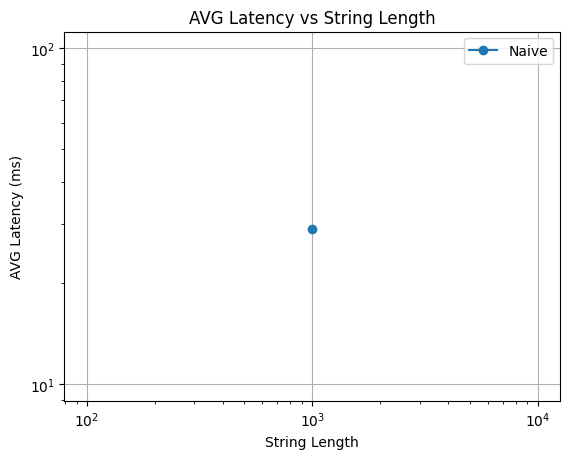

In [23]:
plt.plot(df_na_all['str_len'], df_na_all['latency_ms'], marker='o', label="Naive")

plt.xlabel('String Length')
plt.ylabel('AVG Latency (ms)')
plt.title('AVG Latency vs String Length')
plt.legend()
plt.grid()

plt.xscale("log")
plt.yscale("log")

plt.show()

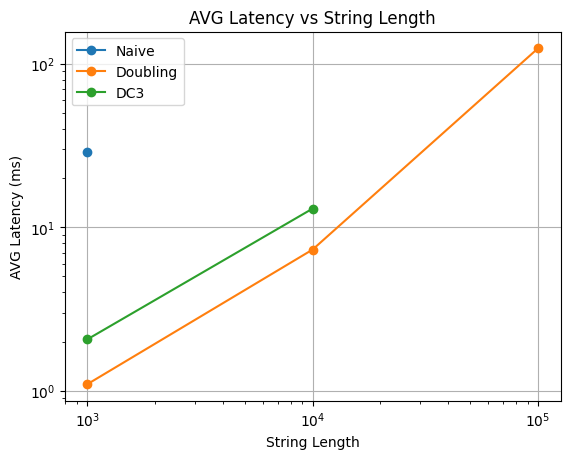

In [24]:
plt.plot(df_na_all['str_len'], df_na_all['latency_ms'], marker='o', label="Naive")
plt.plot(df_db_all['str_len'], df_db_all['latency_ms'], marker='o', label="Doubling")
plt.plot(df_dc3_all['str_len'], df_dc3_all['latency_ms'], marker='o', label="DC3")

plt.xlabel('String Length')
plt.ylabel('AVG Latency (ms)')
plt.title('AVG Latency vs String Length')
plt.legend()
plt.grid()

plt.xscale("log")
plt.yscale("log")

plt.show()

# Latency per Alphabet

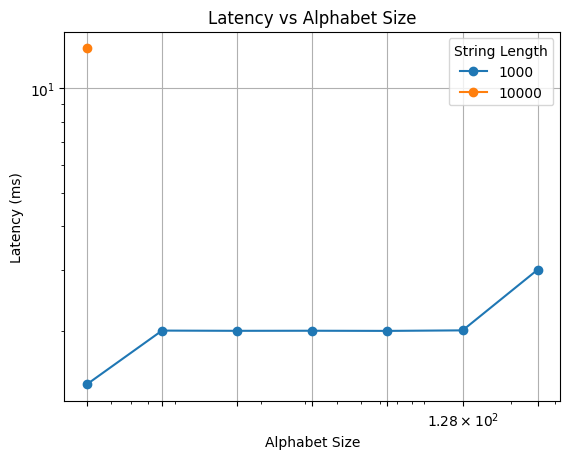

In [25]:
pivot_df = mode_df.pivot(index='alph', columns='str_len', values='latency_ms')

pivot_df.plot(marker='o')

plt.xlabel('Alphabet Size')
plt.ylabel('Latency (ms)')
plt.title('Latency vs Alphabet Size')
plt.grid()

plt.xscale("log")
plt.yscale("log")

plt.legend(title="String Length", loc='upper right')
plt.xticks(pivot_df.index)

plt.show()